# Practical worksheet: DCGAN for training + inference (MNIST + CIFAR-10)

## Learning focus
1. Build a **DCGAN** (convolutional Generator + Discriminator) with BCE adversarial loss.
2. Train DCGAN on **MNIST** (resized to 32x32) and **CIFAR-10**.
3. Save checkpoints and reload generator for **inference**.
4. Render a simple latent-space interpolation to inspect continuity.

## Notebook setup
The next cells install/import dependencies, define reproducibility/device settings, and build reusable data loaders.

In [9]:
%pip install -q tqdm
%matplotlib inline

import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

Note: you may need to restart the kernel to use updated packages.


Define reproducibility and device selection (`cuda`, `mps`, `cpu`).

In [10]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')


set_seed(42)
device = get_device()
print('Device:', device)

Device: mps


Build loaders for MNIST and CIFAR-10 normalized to `[-1, 1]`.

Note: MNIST is resized to **32x32** so we can reuse the same DCGAN architecture.

In [11]:
def build_loaders(
    dataset_name='mnist',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
    data_root='data',
    num_workers=0,
):
    dataset_name = dataset_name.lower()

    if dataset_name == 'mnist':
        channels = 1
        image_size = 32
        transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
        train_ds = datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(data_root, train=False, download=True, transform=transform)
        class_names = [str(i) for i in range(10)]
    elif dataset_name in ('cifar', 'cifar10'):
        channels = 3
        image_size = 32
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        train_ds = datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        class_names = train_ds.classes
    else:
        raise ValueError("dataset_name must be 'mnist' or 'cifar10'.")

    if train_limit is not None:
        train_ds = Subset(train_ds, list(range(min(train_limit, len(train_ds)))))
    if test_limit is not None:
        test_ds = Subset(test_ds, list(range(min(test_limit, len(test_ds)))))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, channels, image_size, class_names

Visual helper: display image grids.

In [12]:
def denorm(x):
    return (x + 1.0) / 2.0


def show_image_grid(images, channels, title='Images', n_show=25):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                if channels == 1:
                    ax.imshow(images[idx, 0], cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### PyTorch docs for key building blocks used here
- `nn.ConvTranspose2d`: https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html
- `nn.Conv2d`: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- `nn.BatchNorm2d`: https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
- `nn.BCELoss`: https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html

Define DCGAN models and helper functions.

Complete TODO blocks for:
- adversarial training cycle (`train_gan`)
- random-sample inference (`run_inference`)
- latent-space interpolation rendering (`latent_walk`)


In [13]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels']).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)


### GAN training algorithm (for `train_gan`)
Use this as the implementation guide for the TODO blocks.

**Key tensors and shapes**
- real batch: `real` has shape `[bs, C, 32, 32]`
- latent batch: `z` has shape `[bs, latent_dim]`
- discriminator output: `[bs, 1]`
- labels: `real_targets = 1`, `fake_targets = 0`, both shape `[bs, 1]`

**Objective (BCE)**
- Discriminator maximizes `log D(x) + log(1 - D(G(z)))`
- Generator maximizes `log D(G(z))` (implemented as BCE with target = 1)

**Per mini-batch procedure**
1. **Discriminator update**
   - `opt_d.zero_grad()`
   - Compute `d_loss_real = BCE(D(real), real_targets)`
   - Sample `z`, generate `fake = G(z)`
   - Compute `d_loss_fake = BCE(D(fake.detach()), fake_targets)`
   - `d_loss = d_loss_real + d_loss_fake`, then `d_loss.backward()` and `opt_d.step()`
2. **Generator update**
   - `opt_g.zero_grad()`
   - Sample fresh `z`, generate `fake = G(z)`
   - Compute `g_loss = BCE(D(fake), real_targets)`
   - `g_loss.backward()` and `opt_g.step()`
3. **Bookkeeping**
   - Accumulate `g_loss.item()` and `d_loss.item()`
   - Increment batch counter and compute epoch means at the end

**Common mistakes to avoid**
- Forgetting `detach()` in discriminator fake pass
- Reusing old `fake` tensor for generator step after optimizer updates
- Using fake targets (0) for generator loss instead of real targets (1)
- Mismatched shapes between logits and target tensors


In [14]:
def train_gan(generator, discriminator, loader, latent_dim, epochs=20, lr=2e-4):
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {'g_loss': [], 'd_loss': []}
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = real.to(device)
            bs = real.size(0)

            real_targets = torch.ones(bs, 1, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)

            # TODO START - Discriminator update
            # 1) Reset discriminator gradients for the new mini-batch.
            opt_d.zero_grad()
            # 2) Measure how well it recognizes real images as real.
            d_loss_real = criterion(discriminator(real), real_targets)
            # 3) Sample latent noise and generate a fake batch.
            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)
            # 4) Measure how well it recognizes fake images as fake.
            d_loss_fake = criterion(discriminator(fake.detach()), fake_targets)
            # 5) Combine both real/fake discriminator losses.
            d_loss = d_loss_real + d_loss_fake
            # 6) Backpropagate discriminator loss and update discriminator weights.
            d_loss.backward()
            opt_d.step()
            # TODO END


            # TODO START - Generator update
            # 1) Reset generator gradients for the new mini-batch.
            opt_g.zero_grad()
            # 2) Sample fresh latent noise and generate a fake batch.
            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)
            # 3) Evaluate how convincing those fake images look to the discriminator.
            g_loss = criterion(discriminator(fake), real_targets)
            # 4) Compute generator loss so fake images are pushed toward "real" predictions.
            # 5) Backpropagate generator loss and update generator weights.
            g_loss.backward()
            opt_g.step()
            
            # TODO END


            # TODO START - Bookkeeping
            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1
            # TODO END

        history['g_loss'].append(g_running / max(n_batches, 1))
        history['d_loss'].append(d_running / max(n_batches, 1))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"D loss: {history['d_loss'][-1]:.4f} | "
            f"G loss: {history['g_loss'][-1]:.4f}"
        )

    return history

## 1 - MNIST DCGAN: train and run inference
Train DCGAN on MNIST (resized to 32x32), then save checkpoint and generate new samples.

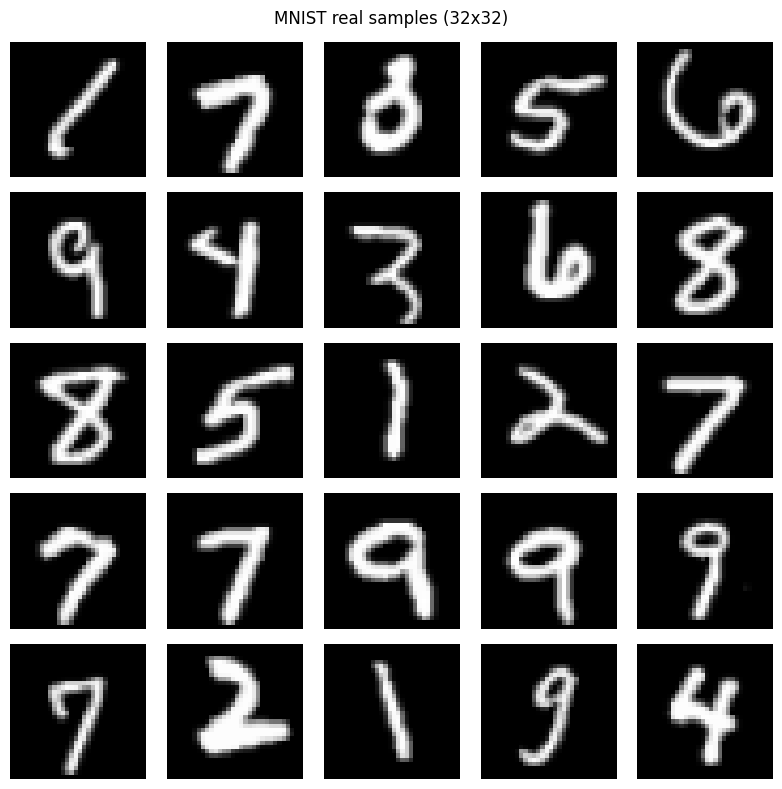

In [15]:
mnist_train_loader, mnist_test_loader, mnist_channels, mnist_image_size, _ = build_loaders(
    dataset_name='mnist',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
)

x_mnist, _ = next(iter(mnist_train_loader))
show_image_grid(x_mnist, channels=mnist_channels, title='MNIST real samples (32x32)', n_show=25)

Train MNIST DCGAN and save checkpoint.

Goal: instantiate the two models, run training, and persist weights for inference.


Epoch 1/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 01/20 | D loss: 0.3905 | G loss: 4.4721


Epoch 2/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 02/20 | D loss: 0.3864 | G loss: 3.1192


Epoch 3/20:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 18/20 | D loss: 0.2707 | G loss: 3.4208


Epoch 19/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19/20 | D loss: 0.0720 | G loss: 4.3441


Epoch 20/20:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 20/20 | D loss: 0.3042 | G loss: 3.7927


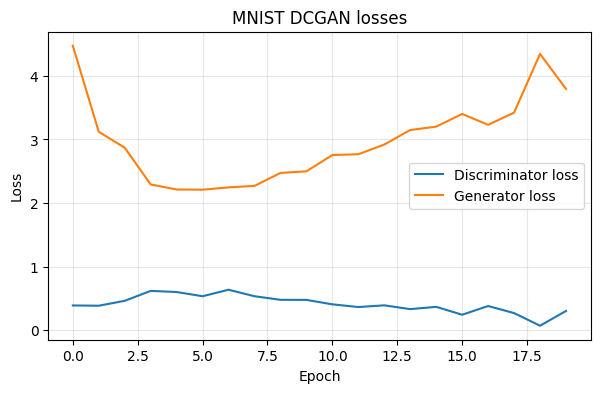

Saved checkpoint to runs/dcgan/mnist_dcgan.pt


In [16]:
# TODO START
mnist_latent_dim = 100
mnist_epochs = 20
mnist_lr = 2e-4
mnist_ckpt = Path('runs/dcgan/mnist_dcgan.pt')

mnist_generator = DCGenerator(mnist_latent_dim, mnist_channels).to(device)
mnist_discriminator = DCDiscriminator(mnist_channels).to(device)
# TODO END

if mnist_generator is None or mnist_discriminator is None:
    raise NotImplementedError('Instantiate MNIST DCGAN models inside TODO block.')

# TODO START
# Recommended: initialize DCGAN weights
mnist_generator.apply(init_dcgan_weights)
mnist_discriminator.apply(init_dcgan_weights)
# TODO END

mnist_history = train_gan(
    generator=mnist_generator,
    discriminator=mnist_discriminator,
    loader=mnist_train_loader,
    latent_dim=mnist_latent_dim,
    epochs=mnist_epochs,
    lr=mnist_lr,
)

plot_gan_losses(mnist_history, title='MNIST DCGAN losses')

save_checkpoint(
    generator=mnist_generator,
    discriminator=mnist_discriminator,
    history=mnist_history,
    checkpoint_path=mnist_ckpt,
    latent_dim=mnist_latent_dim,
    channels=mnist_channels,
    image_size=mnist_image_size,
)

MNIST inference after training.

Goal: load generator checkpoint, render random samples, and render latent interpolation.


In [17]:
@torch.no_grad()
def run_inference(generator, latent_dim, channels, n_samples=25, seed=123, title='Generator inference'):
    # TODO START
    # 1) set torch seed
    torch.manual_seed(seed)
    # 2) sample z
    z = torch.randn(n_samples, latent_dim, device=device)
    # 3) generate fake images
    fake = generator(z)
    # TODO END

    show_image_grid(fake, channels=channels, title=title, n_show=n_samples)


@torch.no_grad()
def latent_walk(generator, latent_dim, channels, steps=10, title='Latent interpolation'):
    # TODO START
    # 1) sample z0 and z1
    z0= torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    # 2) interpolate with alpha in [0, 1]
    alpha = torch.rand(1, device=device)
    z = (1 - alpha) * z0 + alpha * z1
    # 3) generate fake images
    fake = generator(z)
    # TODO END

    show_image_grid(fake, channels=channels, title=title, n_show=steps)


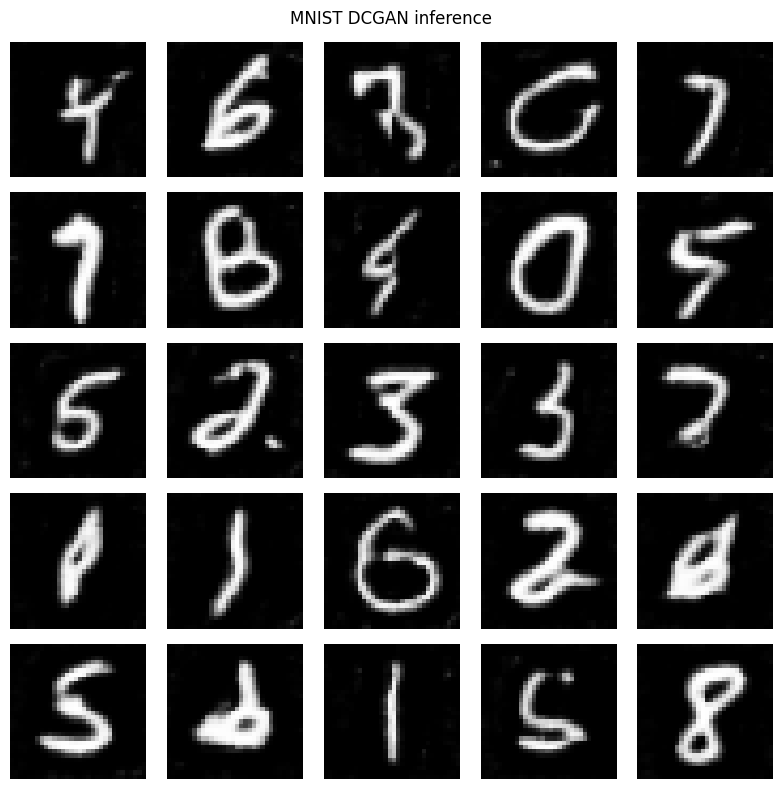

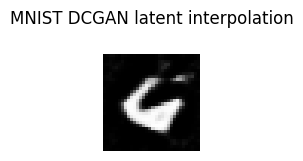

In [18]:
# TODO START
mnist_gen_infer, mnist_cfg, _ = load_dcgan_generator_for_inference(mnist_ckpt)
# TODO END


# TODO START

# Call run_inference(...) and latent_walk(...)
run_inference(
    generator=mnist_gen_infer,
    latent_dim=mnist_cfg['latent_dim'],
    channels=mnist_cfg['channels'],
    n_samples=25,
    seed=123,
    title='MNIST DCGAN inference',
)
latent_walk(
    generator=mnist_gen_infer,
    latent_dim=mnist_cfg['latent_dim'],
    channels=mnist_cfg['channels'],
    steps=10,
    title='MNIST DCGAN latent interpolation',
)
# TODO END

## 2 - CIFAR-10 DCGAN: train and run inference
Repeat the same DCGAN pipeline on CIFAR-10.

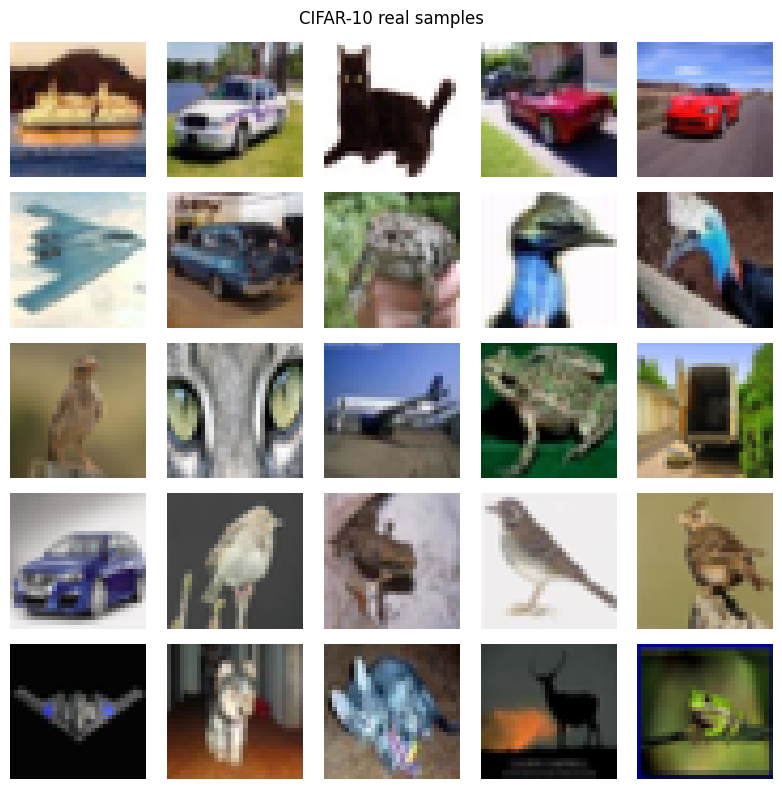

Example labels: ['ship', 'automobile', 'cat', 'automobile', 'automobile', 'airplane', 'automobile', 'frog', 'bird', 'bird']


In [19]:
cifar_train_loader, cifar_test_loader, cifar_channels, cifar_image_size, cifar_class_names = build_loaders(
    dataset_name='cifar10',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
)

x_cifar, y_cifar = next(iter(cifar_train_loader))
show_image_grid(x_cifar, channels=cifar_channels, title='CIFAR-10 real samples', n_show=25)
print('Example labels:', [cifar_class_names[i] for i in y_cifar[:10].tolist()])

Train CIFAR-10 DCGAN and save checkpoint.

Goal: repeat the same DCGAN training/inference pipeline with CIFAR-10 settings.


In [ ]:
# TODO START
cifar_latent_dim = 100
cifar_epochs = 30
cifar_lr = 2e-4
cifar_ckpt = Path('runs/dcgan/cifar10_dcgan.pt')

cifar_generator = DCGenerator(latent_dim=cifar_latent_dim, image_channels=cifar_channels).to(device)
cifar_discriminator = DCDiscriminator(image_channels=cifar_channels).to(device)

# TODO START
# Recommended: initialize DCGAN weights
# cifar_generator.apply(init_dcgan_weights)
# cifar_discriminator.apply(init_dcgan_weights)

# TODO END

cifar_history = train_gan(
    generator=cifar_generator,
    discriminator=cifar_discriminator,
    loader=cifar_train_loader,
    latent_dim=cifar_latent_dim,
    epochs=cifar_epochs,
    lr=cifar_lr,
)

plot_gan_losses(cifar_history, title='CIFAR-10 DCGAN losses')

save_checkpoint(
    generator=cifar_generator,
    discriminator=cifar_discriminator,
    history=cifar_history,
    checkpoint_path=cifar_ckpt,
    latent_dim=cifar_latent_dim,
    channels=cifar_channels,
    image_size=cifar_image_size,
)

Epoch 1/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 01/30 | D loss: 0.4007 | G loss: 4.3094


Epoch 2/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 02/30 | D loss: 0.5011 | G loss: 3.8127


Epoch 3/30:   0%|          | 0/235 [00:00<?, ?it/s]

KeyboardInterrupt: 

CIFAR-10 inference after training.

Goal: load generator checkpoint, render random samples, and render latent interpolation.


In [ ]:
# TODO START
cifar_gen_infer, cifar_cfg, _ = None, None, None
# TODO END

if cifar_gen_infer is None or cifar_cfg is None:
    raise NotImplementedError('Load CIFAR-10 DCGAN checkpoint for inference.')

# TODO START
# Call run_inference(...) and latent_walk(...)
raise NotImplementedError('Run CIFAR-10 DCGAN inference and latent interpolation.')
# TODO END

## Final reflection
1. What differences did you observe between MNIST DCGAN and CIFAR-10 DCGAN stability?
2. Did weight initialization and training length change the sample quality significantly?
3. Which visual cue best indicates early mode collapse in your generated grids?
4. What is the first single hyperparameter you would tune next, and why?


Answers: